In [1]:
## Justin Ogle
## EE 258
## Final Project Code MLP
## Final Code

import numpy as np
import pandas as pd
from pathlib import Path
import os.path
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras import Model
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.models import Sequential
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import (TextArea, DrawingArea, OffsetImage,AnnotationBbox)
import matplotlib.patches as mpatches
import seaborn as sns
import random
import shutil
from shutil import copyfile
# Loop through files in the specified directory
for dirname, _, filenames in os.walk('Desktop/Grad School Homework/EE 258/EE 258 Final Project/Final Project Data'):
    for filename in filenames:
       (os.path.join(dirname, filename))

In [2]:
# Define directories and file paths
train_dir = Path('Desktop/Grad School Homework/EE 258/EE 258 Final Project/Final Project Data/train')
train_filepaths = list(train_dir.glob(r'**/*.jpg'))
valid_dir = Path('Desktop/Grad School Homework/EE 258/EE 258 Final Project/Final Project Data/validation')
valid_filepaths = list(valid_dir.glob(r'**/*.jpg'))
test_dir = Path('Desktop/Grad School Homework/EE 258/EE 258 Final Project/Final Project Data/test')
test_filepaths = list(test_dir.glob(r'**/*.jpg'))
# Define constants
num_classes = 51

In [3]:
# Data augmentation configurations
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

validation_datagen = ImageDataGenerator(
    rescale=1./255
)

In [4]:
# Generate data flows for training, testing, and validation
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=128,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=128,
    class_mode="categorical",
    shuffle=False
)

validation_generator = validation_datagen.flow_from_directory(
    valid_dir,
    target_size=(224, 224),
    batch_size=128,
    class_mode="categorical"
)

Found 4013 images belonging to 51 classes.
Found 474 images belonging to 51 classes.
Found 456 images belonging to 51 classes.


In [5]:
# Create the base model using MobileNetV2
from tensorflow.keras.applications import MobileNetV2
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
# Set base model layers as non-trainable
for layer in base_model.layers:
    layer.trainable = False

In [6]:
# Build the MLP (Multi-Layer Perceptron) model
model = Sequential()
# Flatten the input images to a one-dimensional vector
model.add(Flatten(input_shape=(224, 224, 3)))
# Add a Dense layer with 1024 units and ReLU activation function for feature extraction
model.add(Dense(1024, activation='relu'))
# Add another Dense layer with 512 units and ReLU activation function
model.add(Dense(512, activation='relu'))
# Add the final Dense layer with num_classes units and softmax activation for classification
model.add(Dense(num_classes, activation='softmax'))
# Compile the MLP model with Adam optimizer, categorical cross-entropy loss, and accuracy metric
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [7]:
# Train the model
MLPhistory = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=30
)

Epoch 1/30


C:\Users\jabuu\anaconda3\lib\site-packages\PIL\Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


31/31 [==============================] - 304s 10s/step - loss: 176.2362 - accuracy: 0.0224 - val_loss: 66.4796 - val_accuracy: 0.0286
Epoch 2/30
31/31 [==============================] - 270s 9s/step - loss: 20.4077 - accuracy: 0.0247 - val_loss: 4.7479 - val_accuracy: 0.0339
Epoch 3/30
31/31 [==============================] - 261s 8s/step - loss: 4.0618 - accuracy: 0.0404 - val_loss: 3.8728 - val_accuracy: 0.0417
Epoch 4/30
31/31 [==============================] - 257s 8s/step - loss: 3.6786 - accuracy: 0.0687 - val_loss: 3.3264 - val_accuracy: 0.1224
Epoch 5/30
31/31 [==============================] - 266s 9s/step - loss: 3.3201 - accuracy: 0.1236 - val_loss: 3.0745 - val_accuracy: 0.1589
Epoch 6/30
31/31 [==============================] - 281s 9s/step - loss: 3.1630 - accuracy: 0.1413 - val_loss: 2.9112 - val_accuracy: 0.1797
Epoch 7/30
31/31 [==============================] - 259s 8s/step - loss: 3.0858 - accuracy: 0.1539 - val_loss: 2.8780 - val_accuracy: 0.1901
Epoch 8/30
31/31 [=

In [8]:
# Create a DataFrame to store training history
MLPhistory_df = pd.DataFrame(MLPhistory.history)
MLPhistory_df.head()

,loss,accuracy,val_loss,val_accuracy
0,176.236176,0.022394,66.479637,0.028646
1,20.407688,0.024710,4.747865,0.033854
2,4.061785,0.040412,3.872802,0.041667
3,3.678556,0.068726,3.326410,0.122396
4,3.320068,0.123552,3.074460,0.158854


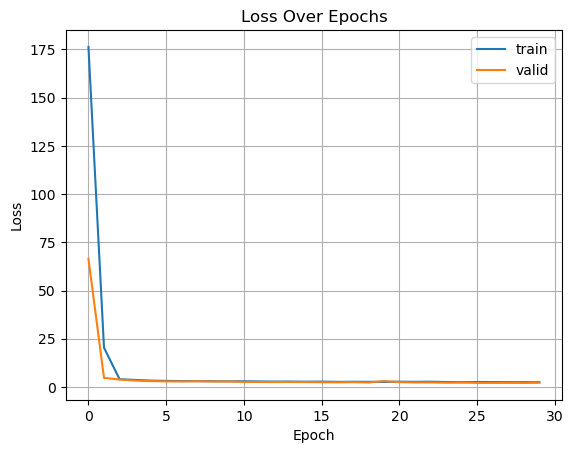

In [9]:
# Plot the loss history
import matplotlib.pyplot as plt
plt.figure()
plt.plot(MLPhistory.history["loss"])
plt.plot(MLPhistory.history["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["train", "valid"])
plt.title("Loss Over Epochs")
plt.grid(True)  # Add a grid
plt.show()

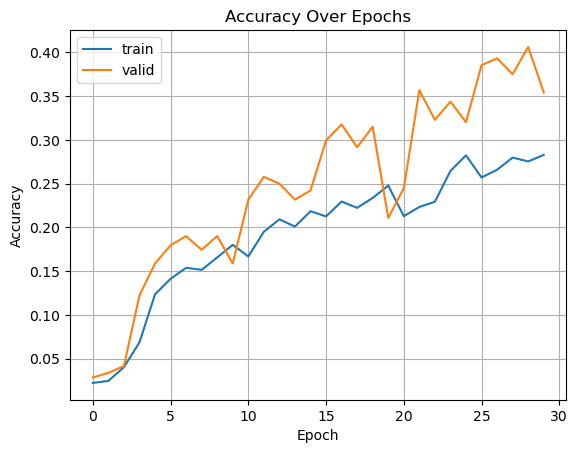

In [10]:
# Plot the accuracy history
plt.figure()
plt.plot(MLPhistory.history["accuracy"])
plt.plot(MLPhistory.history["val_accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["train", "valid"])
plt.title("Accuracy Over Epochs")
plt.grid(True)  # Add a grid
plt.show()

In [11]:
# Make predictions on the test data
MLPpreds = model.predict(test_generator)

4/4 [==============================] - 45s 13s/step


In [12]:
MLPy_pred = np.argmax(MLPpreds, axis=1)

In [13]:
# Print class indices
for k, v in test_generator.class_indices.items():
    print(v, ":", k)

0 : apple
1 : banana
2 : beetroot
3 : bell pepper
4 : blackberry
5 : blueberry
6 : cabbage
7 : capsicum
8 : carrot
9 : cauliflower
10 : cherry
11 : chilli pepper
12 : corn
13 : cucumber
14 : dragonfruit
15 : eggplant
16 : garlic
17 : ginger
18 : grapes
19 : honeydew
20 : jackfruit
21 : jalepeno
22 : kiwi
23 : lemon
24 : lettuce
25 : mango
26 : mushroom
27 : olive
28 : onion
29 : orange
30 : papaya
31 : paprika
32 : parsnip
33 : pear
34 : peas
35 : pineapple
36 : plum
37 : pomegranate
38 : potato
39 : raddish
40 : raspberry
41 : rutabaga
42 : soy beans
43 : spinach
44 : strawberry
45 : sweetcorn
46 : sweetpotato
47 : tomato
48 : turnip
49 : unknown
50 : watermelon


In [14]:
# Define a mapping of class indices to class names
pred_classes = {
    0 : "apple",
    1 : "banana",
    2 : "beetroot",
    3 : "bell pepper",
    4 : "blackberry",
    5 : "blueberry",
    6 : "cabbage",
    7 : "capsicum",
    8 : "carrot",
    9 : "cauliflower",
    10 : "cherry",
    11 : "chilli pepper",
    12 : "corn",
    13 : "cucumber",
    14 : "dragonfruit",
    15 : "eggplant",
    16 : "garlic",
    17 : "ginger",
    18 : "grapes",
    19 : "jalepeno",
    20 : "jackfruit",
    21 : "jalepeno",
    22 : "kiwi",
    23 : "lemon",
    24 : "lettuce",
    25 : "mango",
    26 : "mushroom",
    27 : "olive",
    28 : "onion",
    29 : "orange",
    30 : "papaya",
    31 : "paprika",
    32 : "parsnip",
    33 : "pear",
    34 : "peas",
    35 : "pineapple",
    36 : "plum",
    37 : "pomegranate",
    38 : "potato",
    39 : "raddish",
    40 : "raspberry",
    41 : "rutabaga",
    42 : "soy beans",
    43 : "spinach",
    44 : "strawberry",
    45 : "sweetcorn",
    46 : "sweetpotato",
    47 : "tomato",
    48 : "turnip",
    49 : "unknown",
    50 : "watermelon"
}

In [15]:
# Map predicted indices to class names
MLPy_pred = list(map(lambda x: pred_classes[x], MLPy_pred))
MLPy_test = list(map(lambda x: pred_classes[x], test_generator.classes))

In [16]:
# Generate a classification report
from sklearn.metrics import classification_report
print(classification_report(MLPy_pred, MLPy_test))

               precision    recall  f1-score   support

        apple       0.40      0.50      0.44         8
       banana       0.11      0.50      0.18         2
     beetroot       0.60      0.60      0.60        10
  bell pepper       0.30      0.33      0.32         9
   blackberry       0.56      0.62      0.59         8
    blueberry       0.50      0.43      0.46         7
      cabbage       0.90      0.60      0.72        15
     capsicum       0.00      0.00      0.00         0
       carrot       0.50      0.42      0.45        12
  cauliflower       0.80      0.29      0.42        28
       cherry       0.22      0.67      0.33         3
chilli pepper       0.00      0.00      0.00         0
         corn       0.00      0.00      0.00         0
     cucumber       0.70      0.32      0.44        22
  dragonfruit       0.00      0.00      0.00         4
     eggplant       0.60      0.60      0.60        10
       garlic       0.20      0.15      0.17        13
       gi

C:\Users\jabuu\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\jabuu\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\jabuu\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [17]:
# Define a directory for additional image testing
imgTest_dir = Path('Desktop/Grad School Homework/EE 258/EE 258 Final Project/Final Project Data/imgTest')
imgTest_filepaths = list(imgTest_dir.glob(r'**/*.jpg'))
# Prepare data augmentation for image testing
imgTest_datagen = ImageDataGenerator(
    rescale=1./255
)
try: imgTest_generator = imgTest_datagen.flow_from_directory(
    imgTest_dir,
    target_size=(224, 224),
    batch_size=1,
    class_mode="categorical",
    shuffle=False
)
except Exception as e:
     print("This is neither a fruit or vegetable:", e ,end == '')
        
# Make predictions on the additional test images
MLPpreds = model.predict(imgTest_generator)
MLPy_pred = np.argmax(MLPpreds, axis=1)
# Map predicted indices to class names for additional test images
MLPy_pred = list(map(lambda x: pred_classes[x], MLPy_pred))
print(MLPy_pred)
print("")
print("MLP Final Results")
print("")
print("What are these images? ",MLPy_pred)
# Classify the results into vegetables, fruits, and unknown categories
vegetables = []
fruits = []
unknown = []

for filename in MLPy_pred:
    if "beetroot" in filename or "bell pepper" in filename or "cabbage" in filename or "capsicum" in filename or "carrot" in filename or "cauliflower" in filename or "chilli pepper" in filename or "corn" in filename or "cucumber" in filename or "eggplant" in filename or "garlic" in filename or "ginger" in filename or "jalapeno" in filename or "lettuce" in filename or "mushroom" in filename or "olives" in filename or "onion" in filename or "paprika" in filename or "parsnip" in filename or "peas" in filename or "potato" in filename or "radish" in filename or "rutabaga" in filename or "soybeans" in filename or "spinach" in filename or "sweetpotato" in filename or "sweetcorn" in filename or "tomato" in filename or "turnip" in filename :
        vegetables.append(filename)
    elif "apple" in filename or "banana" in filename or "blackberry" in filename or "blueberry" in filename or "cherry" in filename or "dragonfruit" in filename or "grapes" in filename or "honeydew" in filename or "jackfruit" in filename or "kiwi" in filename or "lemon" in filename or "mango" in filename or "orange" in filename or "papaya" in filename or "pear" in filename or "pineapple" in filename or "pomegranate" in filename or "plum" in filename or "raspberry" in filename or "strawberry" in filename or "watermelon" in filename:
        fruits.append(filename)
    else:
        unknown.append(filename)
print("")
print("Which of these are vegetables, fruits, or not a type of produce?")
print("")
print("Fruits:", fruits)
print("")
print("Vegetables:", vegetables)
print("")
print ("Not a type of produce:", unknown)

Found 47 images belonging to 1 classes.
 5/47 [==>...........................] - ETA: 2s

C:\Users\jabuu\anaconda3\lib\site-packages\PIL\Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


47/47 [==============================] - 4s 80ms/step
['watermelon', 'cucumber', 'garlic', 'apple', 'parsnip', 'pomegranate', 'tomato', 'potato', 'cauliflower', 'cabbage', 'sweetcorn', 'sweetcorn', 'sweetcorn', 'pomegranate', 'soy beans', 'strawberry', 'cucumber', 'onion', 'strawberry', 'soy beans', 'kiwi', 'cabbage', 'grapes', 'garlic', 'kiwi', 'kiwi', 'turnip', 'turnip', 'ginger', 'eggplant', 'strawberry', 'paprika', 'lemon', 'onion', 'pear', 'kiwi', 'soy beans', 'onion', 'raddish', 'pear', 'apple', 'cauliflower', 'turnip', 'sweetpotato', 'soy beans', 'ginger', 'potato']

MLP Final Results

What are these images?  ['watermelon', 'cucumber', 'garlic', 'apple', 'parsnip', 'pomegranate', 'tomato', 'potato', 'cauliflower', 'cabbage', 'sweetcorn', 'sweetcorn', 'sweetcorn', 'pomegranate', 'soy beans', 'strawberry', 'cucumber', 'onion', 'strawberry', 'soy beans', 'kiwi', 'cabbage', 'grapes', 'garlic', 'kiwi', 'kiwi', 'turnip', 'turnip', 'ginger', 'eggplant', 'strawberry', 'paprika', 'lemon'